# SentinelMail — BERT Fine-Tuned: Training & Evaluation

Fine-tunes `bert-base-uncased` via `models.bert.train.fit()` and evaluates it once on the untouched `validation` TEST split. Saves metrics to `evaluation/results/bert_metrics.json` for ensemble comparison.

**Split roles** (comment 001): FIT = 90% of `train` (parameter training) · DEV = seeded 10% train-holdout (checkpoint selection only) · TEST = `validation` (untouched, final reporting only).

**Prerequisites**
- `pip install transformers torch`
- HuggingFace model weights downloaded automatically on first run

## 1. Setup

In [15]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

CHECKPOINT_DIR = REPO_ROOT / "models" / "bert" / "checkpoint"
RESULTS_DIR    = REPO_ROOT / "evaluation" / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")


Device: mps


In [16]:
from data.preprocessing import load_split, load_train_holdout, LABEL_COLS
from models.bert.predict import BertDLPDetector
from evaluation import (
    compute_all_metrics,
    classify_errors,
    error_summary,
    plot_confusion_matrices,
    plot_per_label_bars,
    plot_roc_curves,
    plot_pr_curves,
    save_results,
    from_dataframe,
    LABEL_COLS,
)


## 2. Load Data

In [17]:
print("Loading splits...")
# Three split roles (comment 001):
#   FIT  — 90% of `train`: model parameter training (used inside fit()).
#   DEV  — seeded 10% train-holdout: early stopping / checkpoint selection only.
#   TEST — the ai4privacy `validation` split: untouched, final reporting only.
train_df, dev_df = load_train_holdout(frac=0.10, seed=42)
test_df = load_split("validation")

test_texts  = test_df["source_text"].tolist()
test_labels = test_df[LABEL_COLS].values.astype(np.float32)

print(f"Train (FIT):       {len(train_df):,} samples")
print(f"DEV (selection):   {len(dev_df):,} samples")
print(f"TEST (validation): {len(test_df):,} samples")
print()
print("Label distribution (FIT):")
print(train_df[LABEL_COLS].sum().to_string())


Loading splits...
Train (FIT):       26,917 samples
DEV (selection):   2,991 samples
TEST (validation): 7,946 samples

Label distribution (FIT):
benign           3124
PII             23793
financial        5117
confidential    11905


## 3. Train

Delegates to `models.bert.train.fit()` — the exact code path used by `python -m models.bert.train` and the k-fold CV orchestrator, so notebook and CLI training are identical. `fit()` trains on the 90% FIT slice and selects the checkpoint on the 10% train-holdout DEV (best DEV macro-F1). The `validation` TEST split is **never read during training**.

**Note:** running this cell always retrains and overwrites `checkpoint/best_model.pt` (and takes hours on MPS).

In [18]:
from argparse import Namespace
from models.bert.train import fit

CKPT = CHECKPOINT_DIR / "best_model.pt"
args = Namespace(epochs=5, batch_size=16, lr=2e-5)

ckpt_path, best_dev_f1 = fit(train_df, dev_df, args, CKPT, device=DEVICE)


Device: mps
Train: 26,917  |  Selection holdout: 2,991
Encoding inputs...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8497.41it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Params: 109,485,316 total, 14,769,412 trainable
Epoch 01/5  train=0.5990  val=0.4867  macro-F1=0.9138  ✓ saved
Epoch 02/5  train=0.4685  val=0.4584  macro-F1=0.9313  ✓ saved
Epoch 03/5  train=0.4500  val=0.4551  macro-F1=0.9417  ✓ saved
Epoch 04/5  train=0.4411  val=0.4518  macro-F1=0.9413
Epoch 05/5  train=0.4357  val=0.4481  macro-F1=0.9441  ✓ saved

Best val macro-F1: 0.9441  →  /Users/erelv/projects-chkp/final-project/models/bert/checkpoint/best_model.pt


## 4. Load Best Checkpoint

In [19]:
CKPT = CHECKPOINT_DIR / "best_model.pt"

detector = BertDLPDetector(
    checkpoint_path=str(CKPT),
    device=str(DEVICE),
)
print(f"Loaded: {CKPT.name}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7822.33it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: best_model.pt


## 5. Run Inference on the TEST Split (`validation`)

In [20]:
THRESHOLD = 0.5

print(f"Running predict_proba on {len(test_texts):,} samples...")
y_proba = detector.predict_proba(test_texts)       # (N, 4) float32
y_pred  = (y_proba >= THRESHOLD).astype(np.int32) # (N, 4) int
y_true  = from_dataframe(test_df)                   # (N, 4) int

print(f"y_proba range: [{y_proba.min():.3f}, {y_proba.max():.3f}]")
print()
print(f"{'label':14s}  {'pred':>6s}  {'true':>6s}")
for i, col in enumerate(LABEL_COLS):
    print(f"  {col:12s}  {y_pred[:,i].sum():6d}  {y_true[:,i].sum():6d}")

Running predict_proba on 7,946 samples...
y_proba range: [0.002, 0.998]

label             pred    true
  benign          1024     908
  PII             6921    7038
  financial       1593    1529
  confidential    3718    3632


## 6. Metrics

In [21]:
metrics = compute_all_metrics(y_true, y_pred, y_proba=y_proba)

ci = metrics["macro_f1_ci"]
print(f"Macro-F1:      {metrics['macro_f1']:.4f}  "
      f"(95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}])")
print(f"Macro AUC-ROC: {metrics['auc_roc']['macro']:.4f}")
print()

pd.DataFrame(metrics["per_label"]).T.round(4)

Macro-F1:      0.9596  (95% CI: [0.9560, 0.9637])
Macro AUC-ROC: 0.9915



,precision,recall,f1,support
benign,0.8535,0.9626,0.9048,908.0
PII,0.9951,0.9785,0.9867,7038.0
financial,0.9033,0.9411,0.9218,1529.0
confidential,0.9591,0.9818,0.9703,3632.0


### 6a. Threshold Sensitivity (0.3 / 0.5 / 0.7)

In [22]:
rows = []
for t in [0.3, 0.5, 0.7]:
    m   = compute_all_metrics(y_true, (y_proba >= t).astype(np.int32), n_bootstrap=50)
    row = {"threshold": t, "macro_f1": round(m["macro_f1"], 4)}
    for label in LABEL_COLS:
        row[f"{label}_f1"] = round(m["per_label"][label]["f1"], 4)
    rows.append(row)

pd.DataFrame(rows).set_index("threshold")

,macro_f1,benign_f1,PII_f1,financial_f1,confidential_f1
threshold,,,,,
0.3,0.9380,0.6189,0.9897,0.8576,0.9668
0.5,0.9596,0.9048,0.9867,0.9218,0.9703
0.7,0.9327,0.9249,0.8950,0.9328,0.9703


## 7. Confusion Matrices & Per-Label Bars

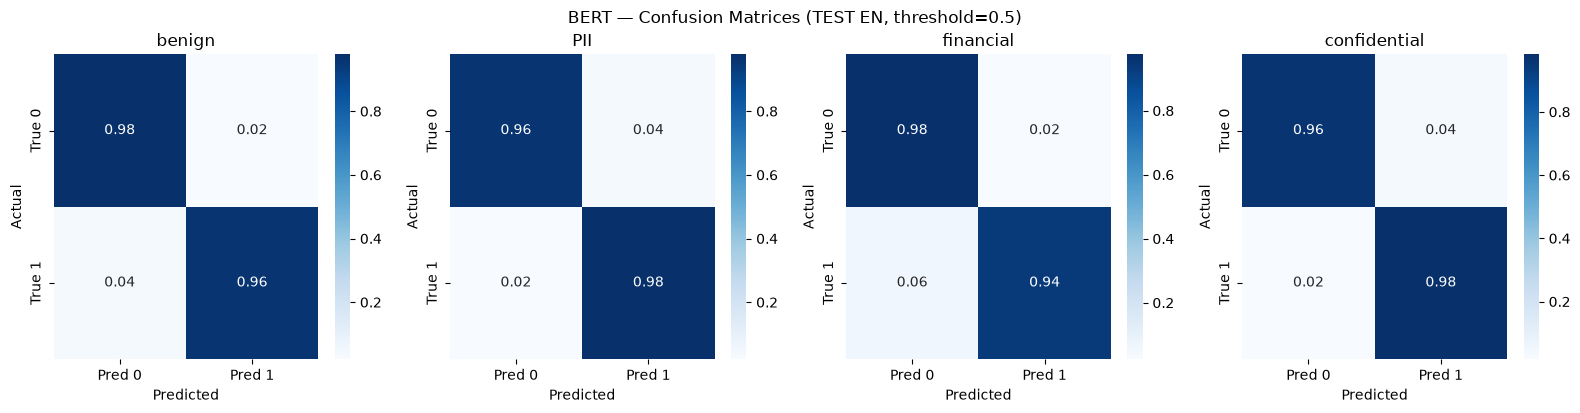

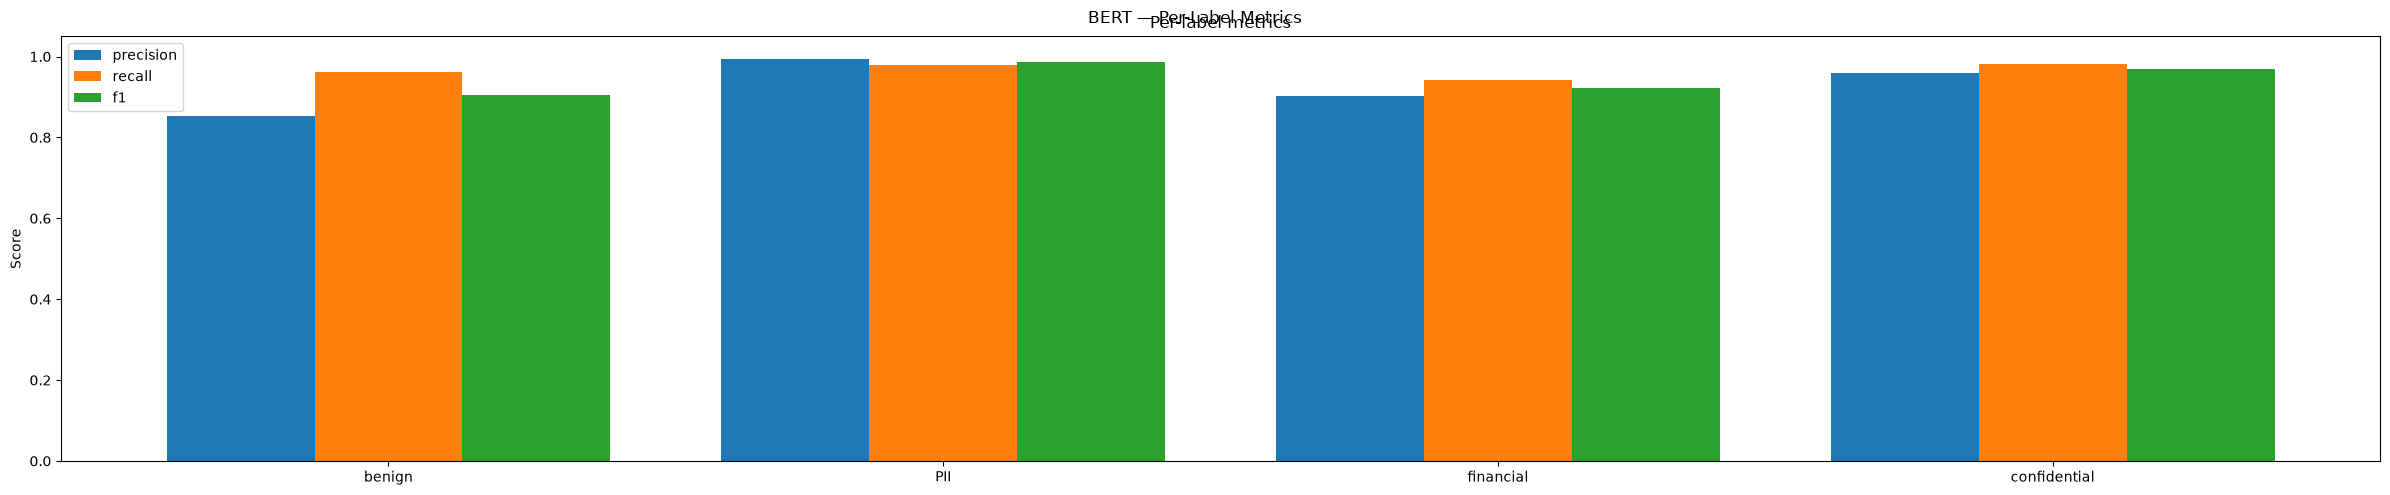

In [23]:
_, fig = plot_confusion_matrices(y_true, y_pred, normalize="true", return_fig=True)
fig.suptitle("BERT — Confusion Matrices (TEST EN, threshold=0.5)", y=1.02)
plt.show()

_, bar_fig = plot_per_label_bars(metrics, return_fig=True)
bar_fig.suptitle("BERT — Per-Label Metrics")
plt.show()

## 8. ROC & PR Curves

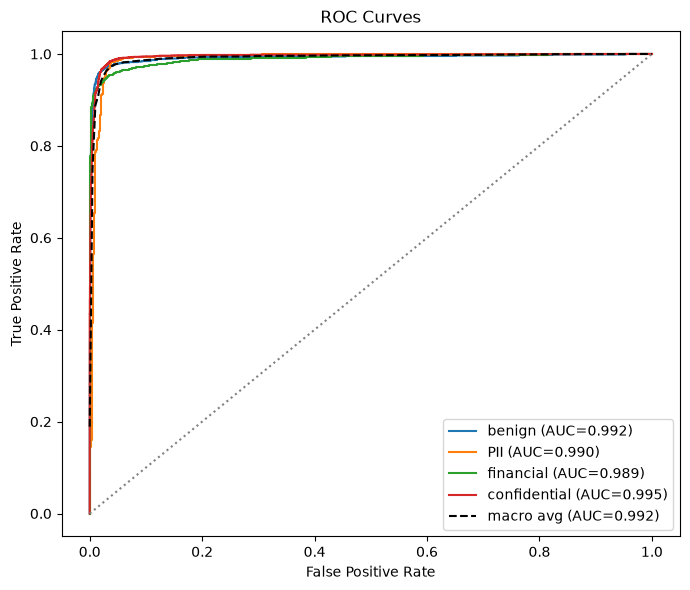

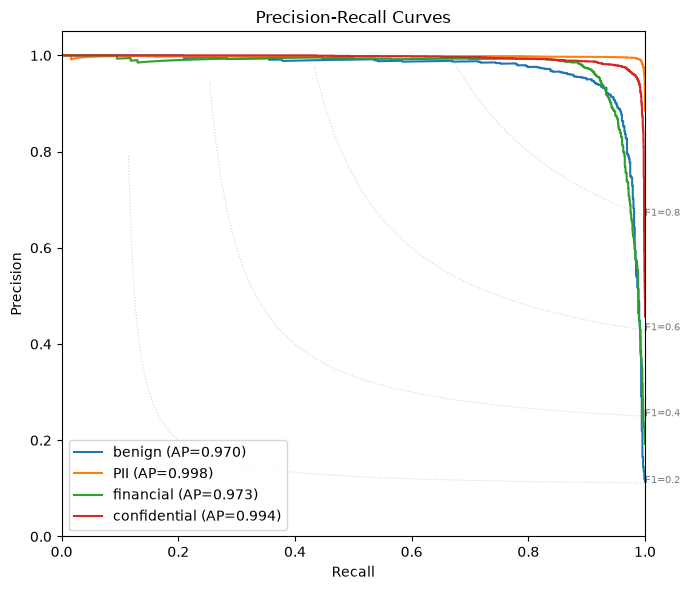

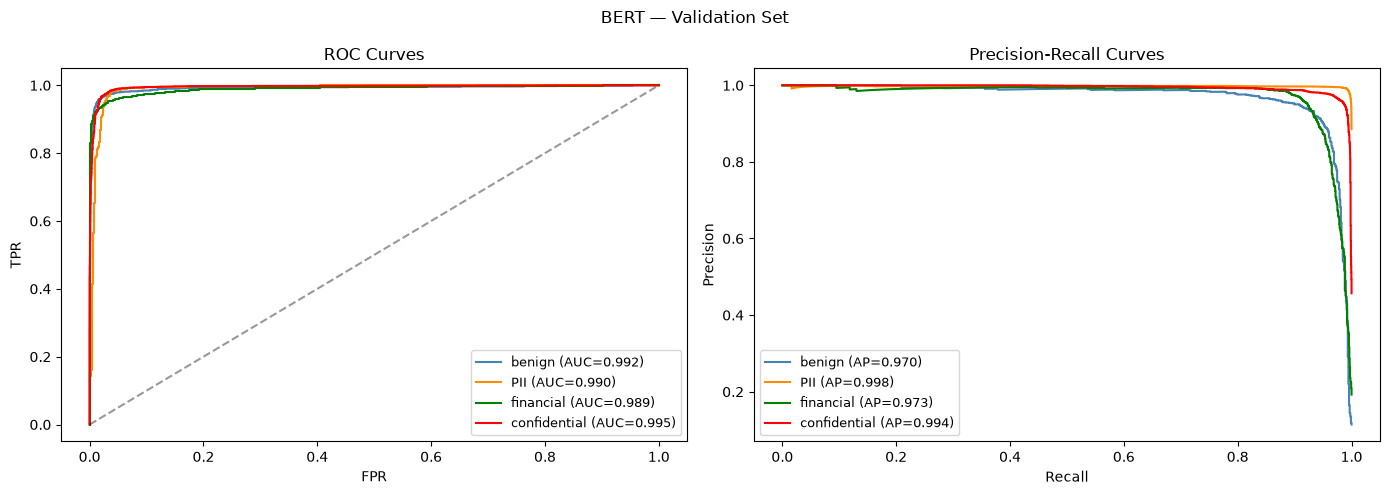

In [24]:
roc_data = plot_roc_curves(y_true, y_proba)
pr_data  = plot_pr_curves(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ["steelblue", "darkorange", "green", "red"]

for i, label in enumerate(LABEL_COLS):
    axes[0].plot(roc_data[label]["fpr"], roc_data[label]["tpr"],
                 label=f"{label} (AUC={roc_data[label]['auc']:.3f})", color=COLORS[i])
    axes[1].plot(pr_data[label]["recall"], pr_data[label]["precision"],
                 label=f"{label} (AP={pr_data[label]['ap']:.3f})", color=COLORS[i])

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=9)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(fontsize=9)
fig.suptitle("BERT — Validation Set")
plt.tight_layout()
plt.show()

## 9. Error Analysis

Classifies FP/FN into the four taxonomy buckets (descriptive error analysis for RQ1/RQ2 model comparison).

In [25]:
texts = test_df["source_text"].tolist()

error_results = classify_errors(
    texts, y_true, y_pred,
    max_examples=20,
)

summary_df = error_summary(error_results)
print("Error counts by type and label:")
display(summary_df.pivot(index="error_type", columns="label", values="count").fillna(0).astype(int))

Error counts by type and label:


label,PII,benign,confidential,financial
error_type,,,,
FN_implicit,0,1,6,3
FN_obfuscated,1,0,9,3
FP_hypothetical,1,4,4,2
FP_negation,3,20,11,10
other_FN,20,20,20,20
other_FP,20,20,20,20


In [26]:
def show_bucket(key: str, n: int = 5) -> None:
    records = error_results.get(key, [])
    print(f"\n{'─'*60}")
    print(f"{key}  ({len(records)} total, showing {min(n, len(records))})")
    print(f"{'─'*60}")
    for r in records[:n]:
        print(f"  [{r['label']}] {r['text_snippet'][:120].replace(chr(10), ' ')}")

show_bucket("FP_negation")
show_bucket("FP_hypothetical")
show_bucket("FN_obfuscated")
show_bucket("FN_implicit")


────────────────────────────────────────────────────────────
FP_negation  (44 total, showing 5)
────────────────────────────────────────────────────────────
  [financial] ect:  1. M    - 0090106547     2. F    - CHAVA.358139.CA.411     3. M    - AUSTI 711154 AS 852     4. F    - THRES.86208
  [financial] 17\tAssessment Feedback Report\tReport providing students with feedback on their performance in assessments. Feminine\Ja
  [confidential] 17\tAssessment Feedback Report\tReport providing students with feedback on their performance in assessments. Feminine\Ja
  [financial] al battlefield. Engage in battles of wits and strategy as you navigate through challenging levels and quests.  Compete w
  [benign] Confidentiality Agreement  This Confidentiality Agreement ("Agreement") is entered into on [DATE], between the parties [

────────────────────────────────────────────────────────────
FP_hypothetical  (11 total, showing 5)
────────────────────────────────────────────────────────────
  [PI

## 10. Save Results

In [27]:
out_path = RESULTS_DIR / "bert_metrics.json"

save_results(
    metrics,
    path=out_path,
    model_name="bert_finetuned",
    n_samples=len(test_df),
    threshold=THRESHOLD,
    extra_metadata={
        "epochs": args.epochs,
        "batch_size": args.batch_size,
        "lr": args.lr,
        "base_model": "bert-base-uncased",
        "frozen_blocks": "0-9",
        "label_smoothing": 0.05,
        "checkpoint": str(CKPT),
        "selection_split": "train_holdout(frac=0.10, seed=42)",
        "test_split": "validation",
    },
)

print(f"Saved to {out_path}")


Saved to /Users/erelv/projects-chkp/final-project/evaluation/results/bert_metrics.json


## 11. Cross-Validation Robustness (5-fold on train split)

CV was run on the ai4privacy **train** split; the held-out **validation** (test) split
was never touched. Results show mean ± std across 5 folds, confirming that the
single-run test metrics are not a lucky split.

In [28]:
import json

kfold_path = RESULTS_DIR / "kfold_cv_bert.json"
with open(kfold_path) as f:
    kfold = json.load(f)

agg = kfold["aggregated"]

rows = []
for label in LABEL_COLS:
    cv_mean = agg["per_label"][label]["f1_mean"]
    cv_std  = agg["per_label"][label]["f1_std"]
    test_f1 = metrics["per_label"][label]["f1"]
    rows.append({
        "label":           label,
        "CV mean F1":      round(cv_mean, 4),
        "CV std":          round(cv_std,  4),
        "Test F1":         round(test_f1, 4),
        "delta (test-CV)": round(test_f1 - cv_mean, 4),
    })

rows.append({
    "label":           "MACRO",
    "CV mean F1":      round(agg["macro_f1_mean"], 4),
    "CV std":          round(agg["macro_f1_std"],  4),
    "Test F1":         round(metrics["macro_f1"],  4),
    "delta (test-CV)": round(metrics["macro_f1"] - agg["macro_f1_mean"], 4),
})

cv_df = pd.DataFrame(rows).set_index("label")
print(f"CV config: {agg["configuration"]}  |  k={kfold["k"]}  |  seed={kfold["seed"]}")
display(cv_df)

CV config: solo_bert  |  k=5  |  seed=42


,CV mean F1,CV std,Test F1,delta (test-CV)
label,,,,
benign,0.8952,0.0082,0.9048,0.0096
PII,0.9838,0.0017,0.9867,0.0030
financial,0.9263,0.0060,0.9218,-0.0045
confidential,0.9659,0.0035,0.9703,0.0045
MACRO,0.9587,0.0027,0.9596,0.0010


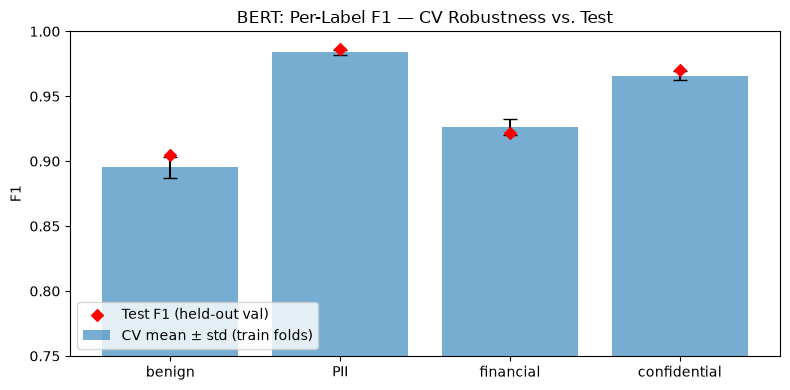

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(LABEL_COLS))
cv_means = [agg["per_label"][l]["f1_mean"] for l in LABEL_COLS]
cv_stds  = [agg["per_label"][l]["f1_std"]  for l in LABEL_COLS]
test_f1s = [metrics["per_label"][l]["f1"] for l in LABEL_COLS]

ax.bar(x, cv_means, yerr=cv_stds, capsize=5, alpha=0.6, label="CV mean ± std (train folds)")
ax.scatter(x, test_f1s, marker="D", color="red", zorder=5, label="Test F1 (held-out val)")
ax.set_xticks(list(x))
ax.set_xticklabels(LABEL_COLS)
ax.set_ylabel("F1")
ax.set_ylim(0.75, 1.0)
ax.set_title("BERT: Per-Label F1 — CV Robustness vs. Test")
ax.legend()
plt.tight_layout()
plt.show()